# Can a thermostat tame Bitcoin? 🌡️
### Vol targeting BTC at 30% — half the heart attacks, but *not* the same ride

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Same_ride%3F: Busted](https://img.shields.io/badge/Same_ride%3F-Busted-8b949e?style=flat-square)

Bitcoin's problem has never been the returns — it's the **−80% winters**. The fix every crypto desk pitches sounds like a thermostat: *"don't hold a fixed amount of Bitcoin, hold a fixed amount of **risk**. When BTC gets wild, own less; when it calms down, own more. Target a constant 30% volatility and you keep the ride while cutting the heart attacks in half."*

It's a real institutional technique (vol targeting runs trillions in equity land). The question is whether the port to a single coin that swings between 20% and 150% vol actually delivers **both** halves of the promise: the smaller crashes *and* the same ride.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the parameter grid? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Data note.** yfinance daily BTC-USD, 2014 → mid-2026 (11.8 years — one asset, one history, and BTC is itself the *surviving* coin of its class). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from btc_vol_targeting import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RET = data.daily_returns()                      # sliced to the study as-of
    OV = st.run_overlay(RET)                        # headline 30% / 30d / 1.5x, gross
else:
    RET = OV = None
print("real BTC cache present:", HAVE_REAL,
      "| days:", (0 if RET is None else len(RET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2014-09-17', 'end': '2026-06-30', 'years': 11.8, 'n_days': 4305, 'n_race': 4274, 'target': 30, 'window': 30, 'cap': 1.5, 's_cagr': 38.12, 's_vol': 35.54, 's_sharpe': 1.087, 's_dd': -52.9, 's_wealth': 43.9, 'b_cagr': 53.63, 'b_vol': 66.5, 'b_sharpe': 0.981, 'b_dd': -83.4, 'b_wealth': 152.6, 'avg_w': 0.604, 'share_lev': 10.1, 'share_cap': 1.1, 'turnover': 6.97, 'gap_ann': -10.64, 't_gap': -1.0, 'alpha': 7.18, 't_alpha': 1.42, 'beta': 0.482, 'appraisal': 0.468, 'vt_median': 31.0, 'vt_p10': 22.4, 'vt_p90': 47.0, 'vt_band': 72.8, 'vt_bh_median': 54.4, 'vt_bh_p90': 95.1, 'crashes': [('2018 bear', -52.61, -83.4), ('COVID 2020', -31.95, -51.86), ('2021-22 bear', -52.86, -76.63), ('full sample', -52.9, -83.4)], 'grid': [(20, 20, 1.018, -40.56, 24.94, 0.91, -1.66), (20, 30, 1.095, -38.61, 26.16, 1.48, -1.49), (20, 60, 1.035, -36.57, 22.95, 0.99, -1.66), (30, 20, 1.018, -53.78, 35.93, 0.9, -1.27), (30, 30, 1.087, -52.9, 38.12, 1.42, -1.0), (30, 60, 1.034, -50.38, 33.71, 0.98, -1.31), (50, 20, 0.971, -75.36, 47.57, 0.44, -0.69), (50, 30, 1.013, -74.01, 50.58, 0.85, -0.27), (50, 60, 1.004, -70.47, 48.91, 0.71, -0.47)], 'costs': [(0, 0, 1.087, 38.12, -52.9, 7.18, 1.42), (5, 0, 1.077, 37.64, -53.04, 6.83, 1.35), (10, 2, 1.066, 37.1, -53.19, 6.44, 1.27), (20, 5, 1.045, 36.07, -53.49, 5.68, 1.13)], 'pl_mean_alpha': 0.23, 'pl_mean_t': 0.06, 'pl_sd_t': 0.97, 'pl_p_alpha': 0.105, 'pl_mean_dd': -67.34, 'pl_p_dd': 0.01, 'pl_seeds': 200, 'giveup': 15.51, 'kept_cagr': 71.1, 'kept_wealth': 28.8, 'syn_null_alpha': 0.21, 'syn_null_t': 0.02, 'syn_null_share': 0, 'syn_pl_alpha': 27.02, 'syn_pl_t': 4.33, 'syn_pl_share': 100, 'fingerprint': '9529d5277775'}


real BTC cache present: True | days: 4304


## The answer first

| Question | Answer |
|---|---|
| Does it tame the −83% drawdowns? | **Yes — genuinely.** Worst crash goes from **-83%** to **-53%**, and a shuffled-signal test shows that's *timing skill*, not just holding less Bitcoin (only 2 in 200 random versions do as well). |
| Does it hold vol at 30%? | **Yes.** The strategy's realized vol hugs the target (median **31%** vs Bitcoin's own 54%). The thermostat works. |
| Is it the *same ride*? | **No.** Over 11.8 years you end with **×44** your money instead of **×153** — less than a third of the buy-and-hold wealth. |
| Does it *beat* Bitcoin risk-adjusted? | **Can't be certified.** The Sharpe nudges up (1.09 vs 0.98) and the alpha is positive (+7.2%/yr) but at *t* = 1.42 it never clears the significance bar. |

> The honest version of the pitch: **"half the heart attacks" is true, "same ride" is false.** You are buying a smoother path, and paying for it with most of the terminal wealth.

## 1 · The claim

> *"Hold `30% ÷ (BTC's recent volatility)` worth of Bitcoin, rebalanced daily (capped at 1.5×). When vol runs at 60%, you hold half a position; at 120%, a quarter; in calm regimes you can lever a little. Same ride, half the heart attacks — the overlay that tames the −83% drawdowns."*

This is the crypto port of **Moreira & Muir (2017)** — the *volatility-managed portfolio* result that made vol scaling academically respectable — plus the institutional folklore of **Harvey et al. (2018)**: vol targeting smooths risk assets because volatility is *forecastable* while returns are not.

We test it exactly as pitched: weight = min(1.5, 30% / trailing-30d realized vol), **yesterday's** vol estimate deciding **today's** position (one-day lag, no peeking), spare cash earning 0%.

## 2 · So what?

Two very different things hide inside the pitch, and they deserve different grades:

1. **Risk control** — *can a mechanical rule hold a wild asset at a chosen volatility and shrink the crashes?* If yes, that's genuinely useful: it's the difference between an allocation you can hold and one that shakes you out at the bottom.
2. **A free lunch** — *do you keep the same growth while taking half the risk?* That's an alpha claim. If it were true, vol-targeted BTC would dominate plain BTC, full stop.

Sales decks love to blur the two. The tape can separate them.

## 3 · How would we even know?

- **The tape.** 4,305 daily BTC-USD closes, 2014-09-17 → 2026-06-30 (11.8 years — three full crypto winters).
- **The rule.** Each day, measure BTC's realized vol over the last 30 days; hold `min(1.5, 30% / vol)` of the portfolio in BTC, rest in cash at 0%. Yesterday's measurement sets today's position — one clean lag.
- **The race.** Vol-targeted BTC vs plain buy & hold on the *same* days: growth, volatility, worst drawdown, Sharpe.
- **The luck test.** Rebuild the strategy 200 times with the vol signal *shuffled in time* (same amount of Bitcoin on average, zero information). If shuffled versions crash just as softly, the "shield" was only *holding less*, not timing.
- **The knob test.** Re-run everything at 20/30/50% targets and 20/30/60-day windows — a real effect shouldn't live in one magic parameter.

## 4 · The teardown — let's actually look

**The ride itself.** Same starting dollar, log scale (each gridline = 10×).

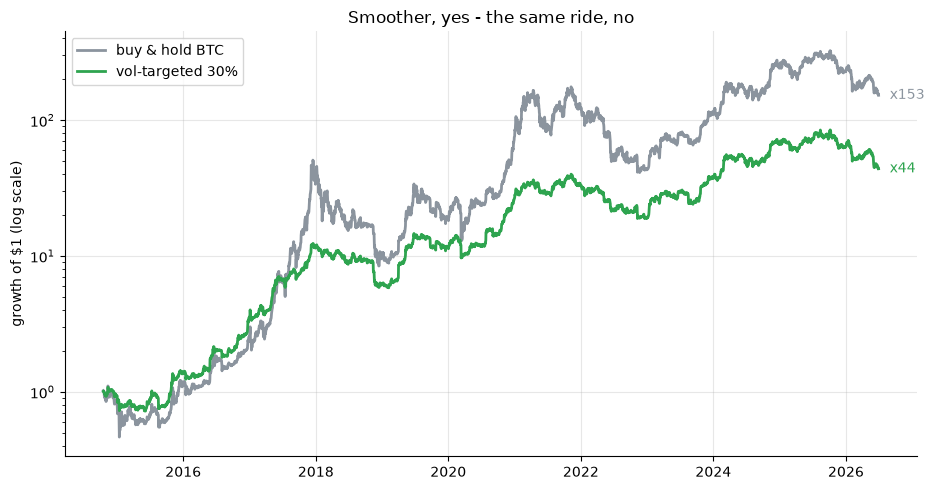

terminal wealth: vol-targeted x43.9  vs  buy & hold x152.6


In [2]:
if HAVE_REAL:
    nav_s = (1 + OV['strat']).cumprod(); nav_b = (1 + OV['bh']).cumprod()
    fig, ax = plt.subplots()
    ax.plot(nav_b.index, nav_b, c=GREY, lw=2, label='buy & hold BTC')
    ax.plot(nav_s.index, nav_s, c=GREEN, lw=2, label='vol-targeted 30%')
    ax.set_yscale('log')
    ax.annotate(f'x{nav_b.iloc[-1]:,.0f}', (nav_b.index[-1], nav_b.iloc[-1]), color=GREY,
                xytext=(8,0), textcoords='offset points', va='center')
    ax.annotate(f'x{nav_s.iloc[-1]:,.0f}', (nav_s.index[-1], nav_s.iloc[-1]), color=GREEN,
                xytext=(8,0), textcoords='offset points', va='center')
    ax.set_ylabel('growth of $1 (log scale)')
    ax.set_title('Smoother, yes - the same ride, no')
    ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
    print(f'terminal wealth: vol-targeted x{nav_s.iloc[-1]:,.1f}  vs  buy & hold x{nav_b.iloc[-1]:,.1f}')
else:
    print('cache missing - frozen numbers:', 'strat x%.1f vs B&H x%.1f' % (R['s_wealth'], R['b_wealth']))

The green line is visibly calmer — and visibly **lower**: **×44** vs **×153**. Keep that trade-off in mind while we check whether each half of the promise holds.

**Half one: the thermostat.** Does the strategy actually *hold* 30% vol while Bitcoin swings all over the place?

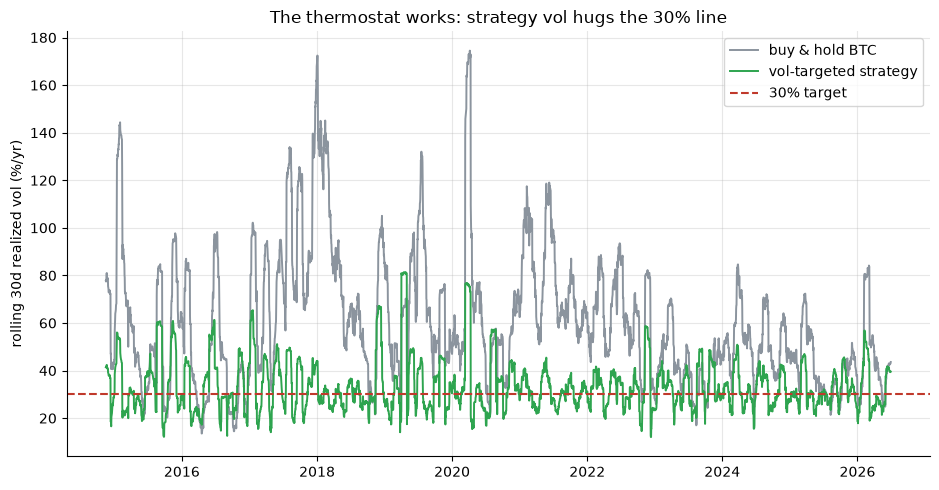

strategy vol: median 31.0%  |  BTC vol: median 54.4%, p90 95.1%


In [3]:
if HAVE_REAL:
    roll_s = OV['strat'].rolling(30).std(ddof=1) * np.sqrt(365) * 100
    roll_b = OV['bh'].rolling(30).std(ddof=1) * np.sqrt(365) * 100
    fig, ax = plt.subplots()
    ax.plot(roll_b.index, roll_b, c=GREY, lw=1.4, label='buy & hold BTC')
    ax.plot(roll_s.index, roll_s, c=GREEN, lw=1.4, label='vol-targeted strategy')
    ax.axhline(30, ls='--', c=RED, lw=1.5, label='30% target')
    ax.set_ylabel('rolling 30d realized vol (%/yr)')
    ax.set_title('The thermostat works: strategy vol hugs the 30% line')
    ax.legend(loc='upper right'); plt.tight_layout(); plt.show()
    print(f'strategy vol: median {roll_s.median():.1f}%  |  BTC vol: median {roll_b.median():.1f}%, p90 {roll_b.quantile(.9):.1f}%')
else:
    print('cache missing - frozen: strategy median %.1f%% vs BTC median %.1f%%' % (R['vt_median'], R['vt_bh_median']))

Confirmed: strategy vol sits at a median **31%** (inside a 20–40% band **73%** of days) while raw BTC careens between 22% and 100%+. The *mechanical* half of the pitch is simply true.

**Half two: the heart attacks.** Worst peak-to-trough loss inside each crypto winter.

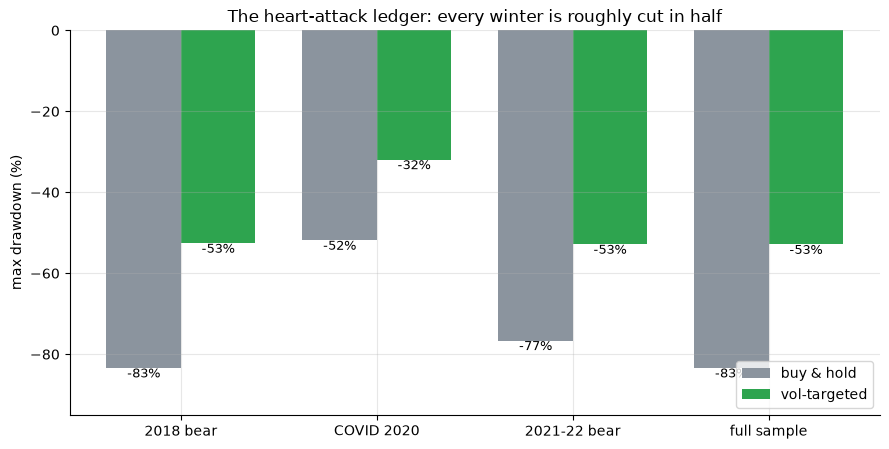

{'2018 bear': (-52.60852935262446, -83.39900882218973), 'COVID 2020': (-31.951866083787806, -51.86169126186413), '2021-22 bear': (-52.85574113904824, -76.63456370856908), 'full sample': (-52.897066664939516, -83.39900882218977)}


In [4]:
names = [c[0] for c in R['crashes']]
sdd = [c[1] for c in R['crashes']]; bdd = [c[2] for c in R['crashes']]
if HAVE_REAL:
    ct = st.crash_table(RET)
    names = list(ct.keys()); sdd = [ct[k]['strat'] for k in names]; bdd = [ct[k]['bh'] for k in names]
x = np.arange(len(names)); wdt = 0.38
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.bar(x - wdt/2, bdd, wdt, color=GREY, label='buy & hold')
ax.bar(x + wdt/2, sdd, wdt, color=GREEN, label='vol-targeted')
for i, v in enumerate(bdd): ax.annotate(f'{v:.0f}%', (x[i]-wdt/2, v), ha='center', va='top', fontsize=9)
for i, v in enumerate(sdd): ax.annotate(f'{v:.0f}%', (x[i]+wdt/2, v), ha='center', va='top', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('max drawdown (%)'); ax.set_ylim(-95, 0)
ax.set_title('The heart-attack ledger: every winter is roughly cut in half')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
print(dict(zip(names, zip(sdd, bdd))))

Every crash shrinks: **-83% → -53%** in 2018, **-77% → -53%** in 2021-22, **-83% → -53%** overall. And the quants notebook shows this is *timing*, not just holding less: 200 shuffled versions of the same rule (same average Bitcoin, no information) average a **−67%** drawdown — only 2 of 200 match the real one. "Half the heart attacks" earns its badge.

**Now the price tag.** Same starting dollar — what did each approach turn it into?

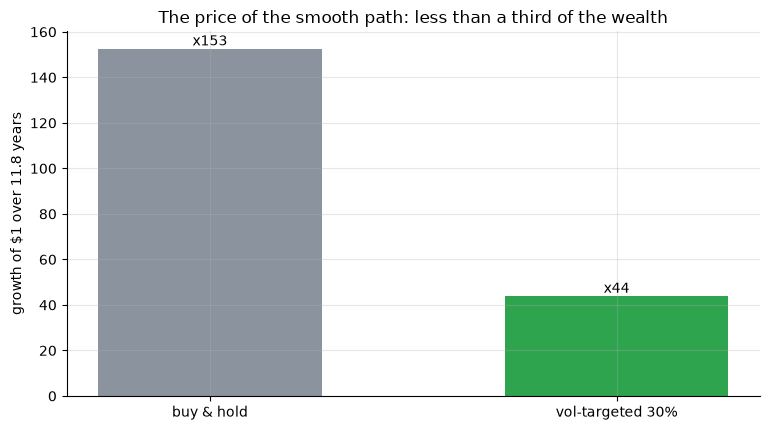

wealth kept: 28.8% of buy & hold


In [5]:
fig, ax = plt.subplots(figsize=(7.8, 4.4))
vals = [R['b_wealth'], R['s_wealth']]
if HAVE_REAL:
    vals = [float((1+OV['bh']).prod()), float((1+OV['strat']).prod())]
ax.bar(['buy & hold', 'vol-targeted 30%'], vals, color=[GREY, GREEN], width=.55)
for i, v in enumerate(vals): ax.annotate(f'x{v:,.0f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('growth of $1 over 11.8 years')
ax.set_title('The price of the smooth path: less than a third of the wealth')
plt.tight_layout(); plt.show()
print(f'wealth kept: {vals[1]/vals[0]*100:.1f}% of buy & hold')

That's the busted half. The overlay kept **71%** of the CAGR (+38%/yr vs +54%/yr — still spectacular), but compounding is merciless: 11.8 years of a 16 pp/yr give-up ends at **29% of the wealth**. "Same ride" it is not.

> 🔬 **For the quants:** the growth gap is *statistically* noise-compatible (HAC *t* = -1.00 — Bitcoin is that loud), and the Sharpe/alpha edge is positive but uncertified (*t* = 1.42). Neither "it costs you growth" nor "it adds alpha" clears the bar; what's certain is the realized arithmetic above.

## 5 · The verdict

- **Signal — Mixed.** *Real on the heart attacks* (drawdowns genuinely halved, certified as timing by the shuffle test), *weak on the ride* (the risk-adjusted edge never clears significance, *t* = 1.42).
- **Tradability — Fragile.** Cheap to run (costs barely dent it) and any exchange can do it — but what survives scrutiny is **risk control, not extra return**, and it cost 16 pp/yr of realized growth on this one 11.8-year tape.
- **"Same ride"? — Busted.** ×44 vs ×153. Half the heart attacks: nearly literal. Same ride: no.

## 6 · Going further 🚪

- **Vol targeting is honest about what it is** — a *risk* dial, not a return machine. If a −50% drawdown is the difference between you holding and you capitulating, giving up wealth for it can be rational. Just buy it with open eyes.
- **The knob is the target.** 20% target → −39% worst crash and a quarter of the wealth; 50% → −74% and half. There is no setting that keeps the wealth *and* kills the crash — the grid in the quants notebook makes that trade-off explicit.
- **Siblings on this desk.** [210-crypto-trend](../../210-crypto-trend/README.md) tames the same drawdowns with an in-or-out SMA rule; [591-vol-managed-portfolio](../../591-vol-managed-portfolio/README.md) tests the same 1/vol recipe on equities, where the alpha claim fares better.

*Think you can pick the vol target that keeps the ride? The grid says otherwise — show us a setting with both halves of the promise and we'll re-grade.*